<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data 
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,      
    random_state=42,    
    stratify=y          
)


print(f"tamanho do treino: {len(y_train)}")
print(f"tamanho do teste: {len(y_test)}")

tamanho do treino: 105
tamanho do teste: 45


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [5]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

acc_treino = clf.score(X_train, y_train)
acc_teste = clf.score(X_test, y_test)

print(f"Acurácia Treino: {acc_treino}")
print(f"Acurácia Teste: {acc_teste}")

Acurácia Treino: 1.0
Acurácia Teste: 0.9333333333333333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

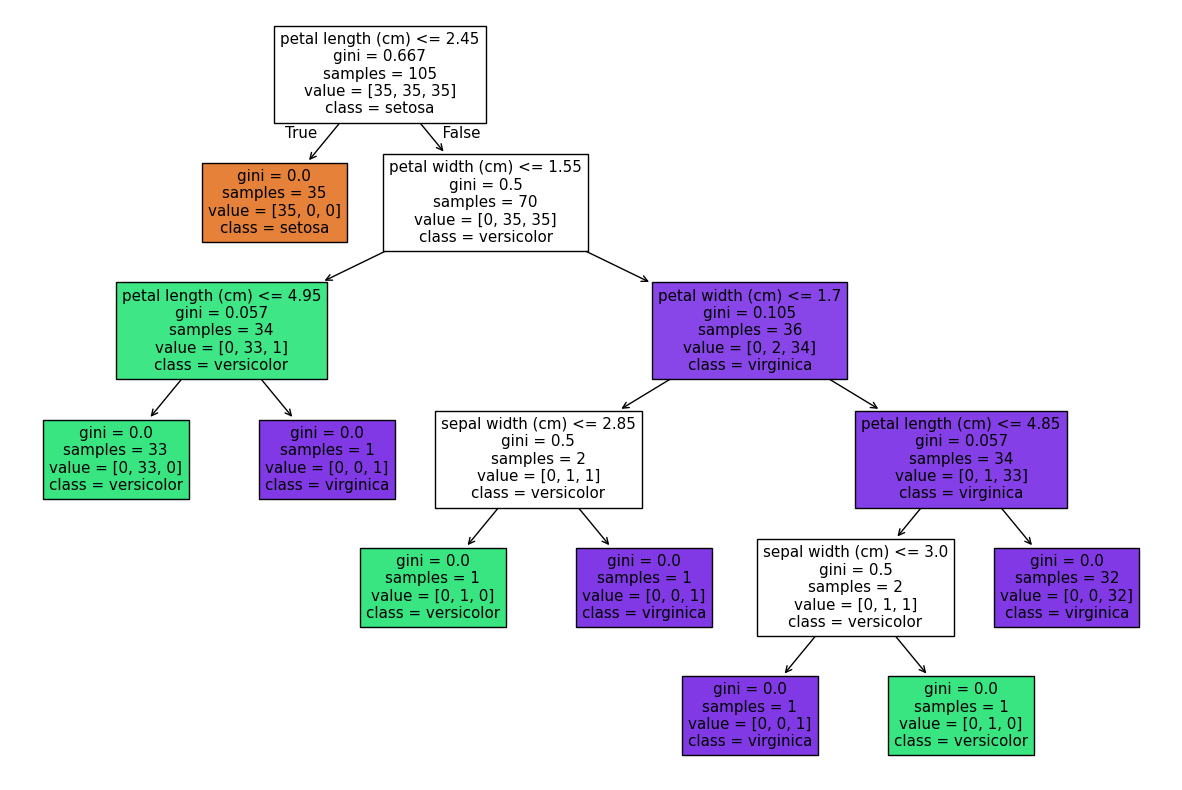

Profundidade da árvore: 5
Atributo da raiz: petal length (cm)


In [9]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

indice_raiz = clf.tree_.feature[0]
atributo_raiz = iris.feature_names[indice_raiz]

print(f"Profundidade da árvore: {clf.get_depth()}")
print(f"Atributo da raiz: {atributo_raiz}")

**Adicione seu texto de solução aqui**.
profundidade: 5 e atributo da raiz é petal lenght em centimetros 



# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [7]:
resultados = []
profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]

for d in profundidades:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    resultados.append({
        "max_depth": d,
        "acuracia_treino": clf.score(X_train, y_train),
        "acuracia_teste": clf.score(X_test, y_test),
        "profundidade_real": clf.get_depth(),
        "num_folhas": clf.get_n_leaves()
    })

import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

   max_depth  acuracia_treino  acuracia_teste  profundidade_real  num_folhas
0        1.0         0.666667        0.666667                  1           2
1        2.0         0.971429        0.888889                  2           3
2        3.0         0.980952        0.977778                  3           5
3        4.0         0.990476        0.888889                  4           7
4        5.0         1.000000        0.933333                  5           8
5        6.0         1.000000        0.933333                  5           8
6        7.0         1.000000        0.933333                  5           8
7        8.0         1.000000        0.933333                  5           8
8        9.0         1.000000        0.933333                  5           8
9        NaN         1.000000        0.933333                  5           8


**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

O overfitting começa no 5, pois a partir dai ele começa a repetir os valores do 4 (acuracia_treino, acuracia_teste, profundidade_real e num_folhas) até o NaN. Como os elementos ficam no mesmo lugar desde da posição 4, sempre o algoritmo vai acertar pois nada muda. 

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [10]:
criterios = ["gini", "entropy"]
comparativo = []

for c in criterios:
    clf_comp = DecisionTreeClassifier(criterion=c, random_state=42)
    clf_comp.fit(X_train, y_train)
    
    comparativo.append({
        "Criterio": c,
        "Profundidade": clf_comp.get_depth(),
        "Acuracia_Teste": clf_comp.score(X_test, y_test)
    })

df_comparativo = pd.DataFrame(comparativo)
print(df_comparativo)

  Criterio  Profundidade  Acuracia_Teste
0     gini             5        0.933333
1  entropy             6        0.888889


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [11]:
import pandas as pd

impacto_folhas = []
valores_leaf = [1, 2, 5, 10, 20, 50]

for m in valores_leaf:
    clf_leaf = DecisionTreeClassifier(min_samples_leaf=m, random_state=42)
    clf_leaf.fit(X_train, y_train)
    
    impacto_folhas.append({
        "min_samples_leaf": m,
        "treino": clf_leaf.score(X_train, y_train),
        "teste": clf_leaf.score(X_test, y_test),
        "folhas_reais": clf_leaf.get_n_leaves()
    })

df_leaf = pd.DataFrame(impacto_folhas)
melhor_idx = df_leaf['teste'].idxmax()
melhor_modelo_info = df_leaf.loc[melhor_idx]

print(df_leaf)
print("\n--- Melhor Modelo Encontrado ---")
print(f"Melhor min_samples_leaf: {melhor_modelo_info['min_samples_leaf']}")
print(f"Acurácia no Teste: {melhor_modelo_info['teste']}")

   min_samples_leaf    treino     teste  folhas_reais
0                 1  1.000000  0.933333             8
1                 2  0.971429  0.888889             6
2                 5  0.971429  0.888889             5
3                10  0.971429  0.888889             5
4                20  0.971429  0.888889             3
5                50  0.666667  0.666667             2

--- Melhor Modelo Encontrado ---
Melhor min_samples_leaf: 1.0
Acurácia no Teste: 0.9333333333333333
